In [ ]:
# Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the
# effect of different learning rates and the number of epochs on model performance.

In [6]:
# Importing the required libraru=ies
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import pandas as pd

Training data: (60000, 28, 28)
Training labels: (60000,)
Testing data: (10000, 28, 28)
Testing labels: (10000,)


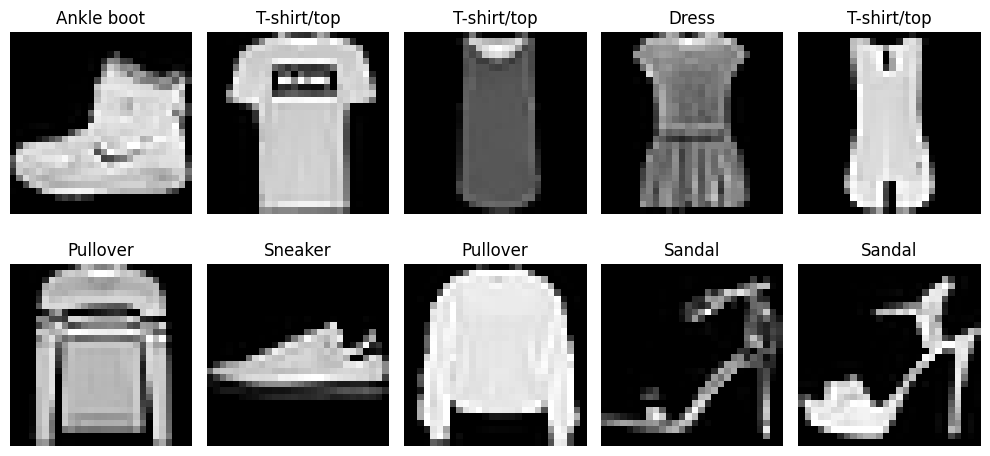

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training data:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing data:", x_test.shape)
print("Testing labels:", y_test.shape)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Preprocess the data and creating the neural network
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

print(x_train.shape)
print(x_test.shape)

# Creating the neural network
def create_model(lr):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(784,)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

(60000, 784)
(10000, 784)


In [10]:
learning_rates = [0.1, 0.01, 0.001]

results = []

for lr in learning_rates:

    print("Training with learning rate:", lr)

    model = create_model(lr)

    model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    results.append([lr, loss, acc])

Training with learning rate: 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training with learning rate: 0.01
Training with learning rate: 0.001


   Learning Rate      Loss  Accuracy
0          0.100  1.065344    0.6370
1          0.010  0.412520    0.8607
2          0.001  0.354005    0.8710


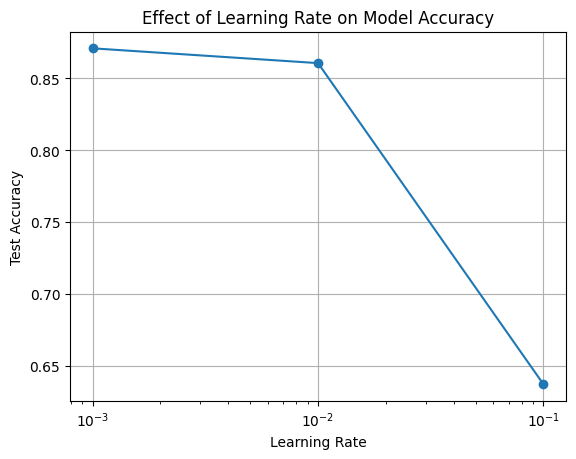

In [11]:
# Displaying the learning-rate results
df = pd.DataFrame(
    results,
    columns=['Learning Rate', 'Loss', 'Accuracy']
)

print(df)

#  plotting learning rate vs accuracy
plt.plot(
    df['Learning Rate'],
    df['Accuracy'],
    marker='o'
)

plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate on Model Accuracy')
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   Epochs      Loss  Accuracy
0       5  0.558748    0.8005
1      10  0.491578    0.8268
2      20  0.428215    0.8465


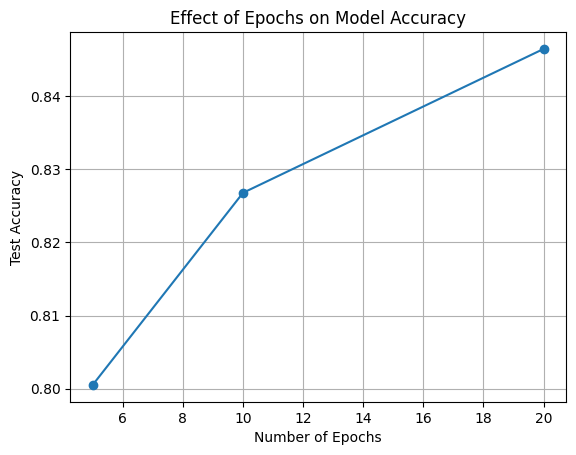

In [13]:
# Testing with diff epochs and plotting an epoch vs accuracy graph
epochs_list = [5, 10, 20]
epoch_results = []

for ep in epochs_list:
    model = create_model(0.001)

    model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=128,
        verbose=0
    )

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    epoch_results.append([ep, loss, acc])

edf = pd.DataFrame(
    epoch_results,
    columns=['Epochs', 'Loss', 'Accuracy']
)

print(edf)

plt.plot(edf['Epochs'], edf['Accuracy'], marker='o')
plt.xlabel('Number of Epochs')
plt.ylabel('Test Accuracy')
plt.title('Effect of Epochs on Model Accuracy')
plt.grid()
plt.show()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5559 - loss: 1.3575 - val_accuracy: 0.6926 - val_loss: 0.8540
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7288 - loss: 0.7530 - val_accuracy: 0.7539 - val_loss: 0.6715
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7641 - loss: 0.6407 - val_accuracy: 0.7788 - val_loss: 0.6040
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7847 - loss: 0.5889 - val_accuracy: 0.7923 - val_loss: 0.5713
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7989 - loss: 0.5564 - val_accuracy: 0.8007 - val_loss: 0.5413
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8120 - loss: 0.5282 - val_accuracy: 0.8134 - val_loss: 0.5198
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8195 - loss: 0.5054 - val_accuracy: 0.8176 - val_loss: 0.4992
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8277 - loss: 0.4875 - val_accuracy: 0.8271 - val_

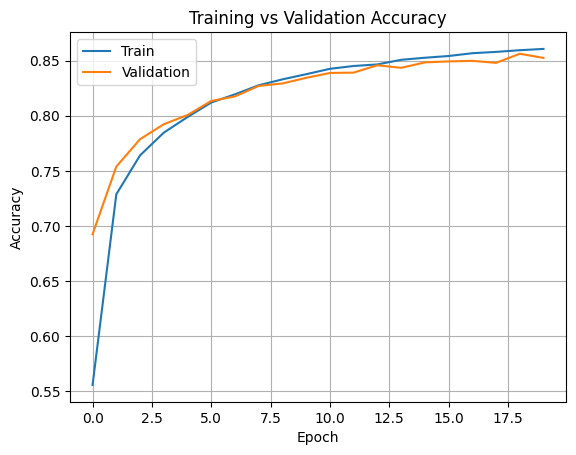

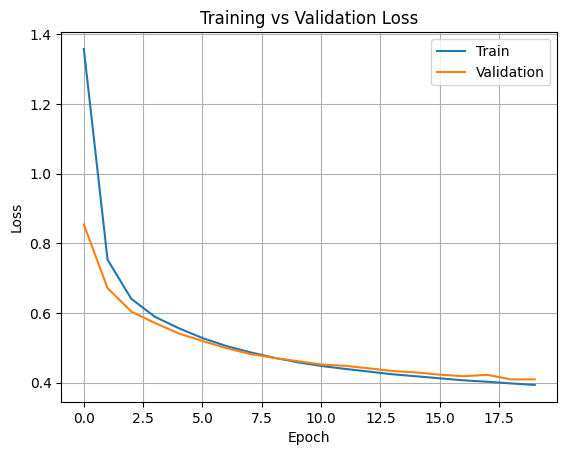

In [14]:
model = create_model(0.001)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128
)

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()

# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train', 'Validation'])
plt.grid()
plt.show()